# COVID-19 Trend Analysis

A reproducible walkthrough. The outputs below are executed results from the pinned public dataset. See the README for full attribution and limitations.

## 1. Reproduce the pipeline

This invokes the same reusable code as the command line. Downloads are verified; cached data work offline.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if not (ROOT / "src").is_dir():
    raise RuntimeError("Open this notebook from the repository root or notebooks directory.")
sys.path.insert(0, str(ROOT))
from src.analysis import run
metrics = run()

{
  "source_geographic_rows": 289,
  "source_daily_cells": 330327,
  "excluded_non_geographic_rows": 2,
  "country_day_records": 227457,
  "countries_and_regions": 199,
  "negative_country_day_revisions": 171,
  "first_day_differences_unavailable": 199,
  "missing_cumulative_values": 0,
  "date_start": "2020-01-22",
  "date_end": "2023-03-09",
  "global_peak_7d_window_end": "2022-01-24",
  "global_peak_7d_net_cases_per_day": 3436897.1428571427,
  "final_cumulative_reported_cases": 676569428,
  "global_negative_revision_days": 0,
  "method": "Province sums; ship rows excluded; first difference unknown; negative revisions retained; trailing 7-day mean."
}


## 2. Inspect the evidence

The source is cumulative and partly provincial. Aggregation precedes differencing. Negative revisions are retained; the first difference is unknown.

In [2]:
pd.Series(metrics, name="Value").to_frame()

,Value
source_geographic_rows,289
source_daily_cells,330327
excluded_non_geographic_rows,2
country_day_records,227457
countries_and_regions,199
negative_country_day_revisions,171
first_day_differences_unavailable,199
missing_cumulative_values,0
date_start,2020-01-22
date_end,2023-03-09


In [3]:
daily = pd.read_csv(ROOT / "reports/global_daily.csv", parse_dates=["date"])
daily.head(10)

,date,cumulative_cases,net_new_cases,new_cases_7d
0,2020-01-22,557,NaN,NaN
1,2020-01-23,657,100.0,NaN
2,2020-01-24,944,287.0,NaN
3,2020-01-25,1437,493.0,NaN
4,2020-01-26,2120,683.0,NaN
5,2020-01-27,2929,809.0,NaN
6,2020-01-28,5580,2651.0,NaN
7,2020-01-29,6169,589.0,801.714286
8,2020-01-30,8237,2068.0,1082.857143
9,2020-01-31,9927,1690.0,1283.285714


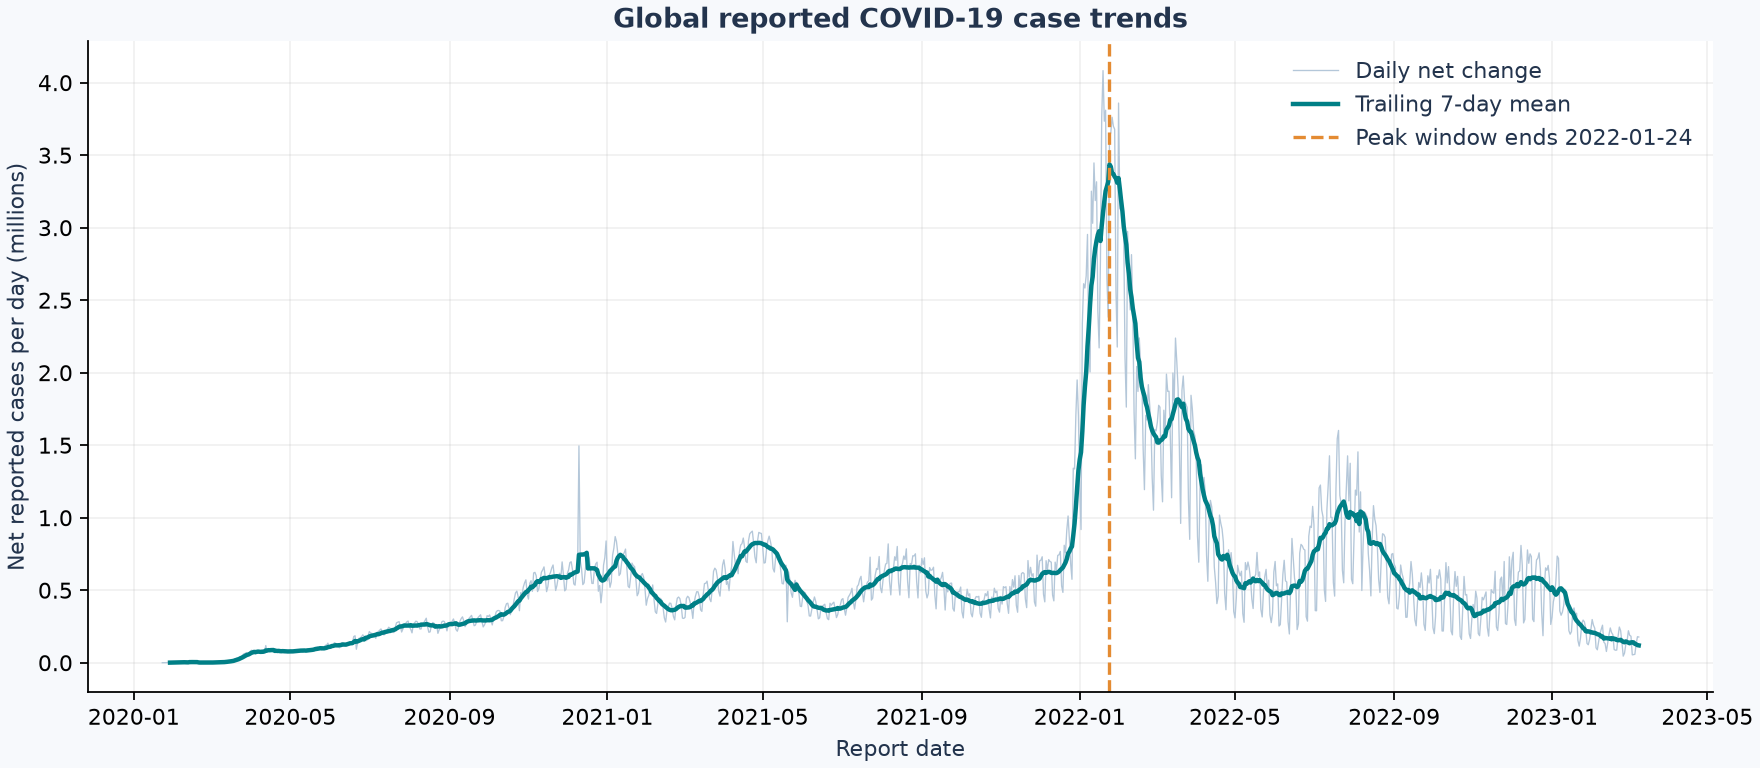

In [4]:
display(Image(filename=str(ROOT / "reports/global_trends.png")))

In [5]:
pd.read_csv(ROOT / "reports/country_peaks.csv").head(10)

,country,date,new_cases_7d
0,US,2022-01-15,806962.857143
1,"Korea, South",2022-03-17,404997.571429
2,India,2021-05-08,391232.000000
3,France,2022-01-25,367017.285714
4,Vietnam,2022-03-18,274025.285714
5,Germany,2022-03-24,229484.142857
6,Japan,2022-08-24,226955.000000
7,United Kingdom,2022-02-01,197997.571429
8,Brazil,2022-01-29,189227.000000
9,Russia,2022-02-15,188712.428571


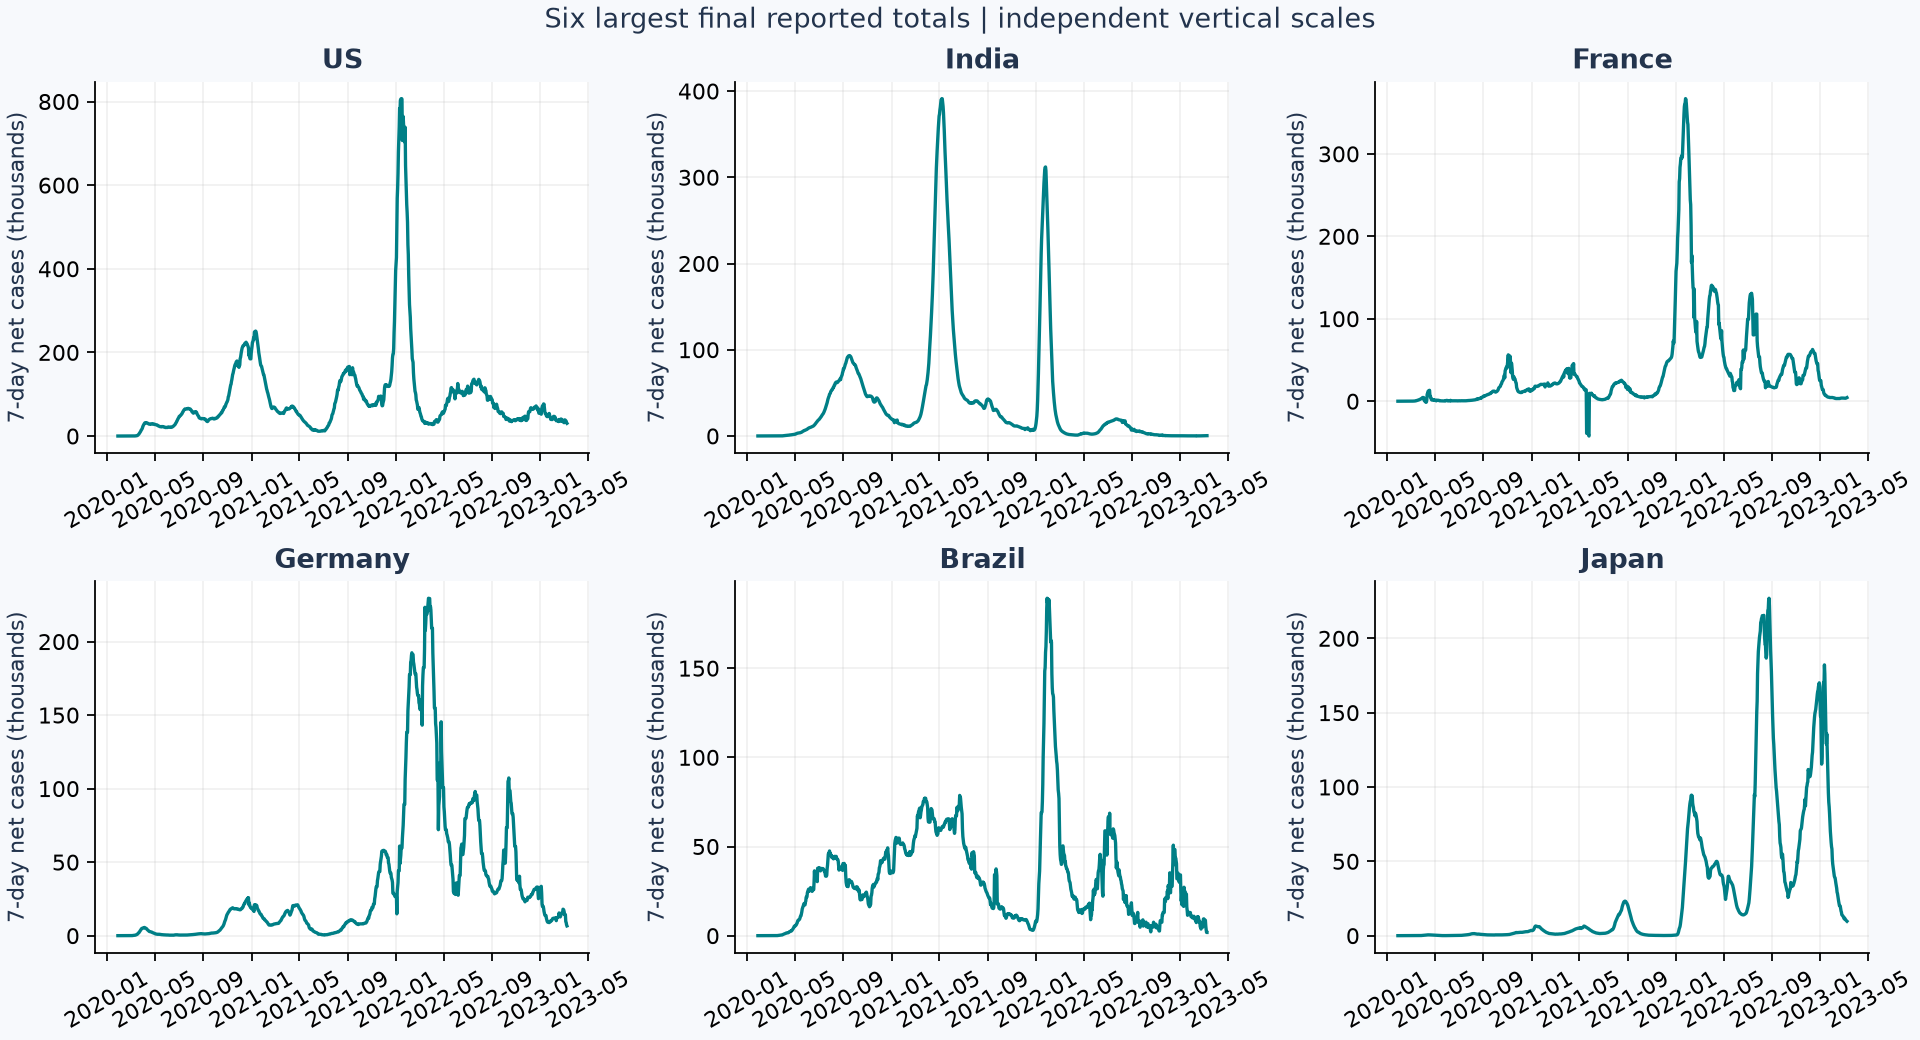

In [6]:
display(Image(filename=str(ROOT / "reports/country_comparison.png")))

## 3. Audit revisions

Corrections may distort rolling peaks. Keeping them preserves the cumulative accounting; clipping would inflate net totals.

In [7]:
pd.read_csv(ROOT / "reports/negative_revisions.csv").head(10)

,country,date,net_new_cases
0,Afghanistan,2020-03-20,-2.0
1,Afghanistan,2022-01-03,-6.0
2,Afghanistan,2023-02-04,-48.0
3,Antigua and Barbuda,2020-07-03,-1.0
4,Antigua and Barbuda,2021-05-09,-1.0
5,Australia,2022-01-31,-26856.0
6,Australia,2022-02-16,-2574.0
7,Australia,2023-02-03,-219.0
8,Austria,2020-02-26,-1.0
9,Austria,2022-09-14,-12934.0


## Interpretation

The largest global seven-day reporting window ends 24 January 2022. Timing differs across countries. These are reported cases, not infection dates or population-normalised risks. Testing and reporting practices limit comparison. The archive ends in March 2023.

Next: compare revision handling and add a versioned population denominator.